# Notebook for Unsupervised ML: Clustering phases with a stronger simple AE

Code inspired by L. Wang, Discovering Phase Transitions with Unsupervised Learning, Phys. Rev. B 94 (2016). https://doi.org/10.1103/PhysRevB.94.195105.

Code generated with assistance of ChatGPT (30 Sept 2025 and 5 May 2026)

## Set up working tree and load packages

In [1]:
%matplotlib inline

import os
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# General sklearn utilities used later for validation
from sklearn.model_selection import train_test_split

# set seeds to make outputs as reproducible as possible
seed = 42
np.random.seed(seed)
random.seed(seed)

mpl.rcParams['text.usetex'] = False

## Mount and load data

In [2]:
N = 80
pkl_path = f"mc_samples_{N}.pickle"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)           # expected structure: dict {temperature: [spin configurations]}

# ------------------------------------------------------------
# Build a data matrix: (number of samples) × (number of lattice sites)
# ------------------------------------------------------------
temps          = sorted(data.keys())          # e.g. 1.6, 1.7, ..., 2.9
samples_per_T  = 100
total_samples  = len(temps) * samples_per_T
flat_size      = N * N

lattice_bank = np.empty((total_samples, flat_size), dtype=np.int8)
labels       = np.empty(total_samples,        dtype=np.float64)

row = 0
for T in temps:
    cfgs = data[T][:samples_per_T]
    for cfg in cfgs:
        # Accept both flattened arrays of length N*N and square N×N arrays.
        lattice_bank[row] = np.asarray(cfg, dtype=np.int8).reshape(-1)
        labels[row]       = float(T)
        row += 1

print("lattice_bank shape:", lattice_bank.shape)
print("labels shape      :", labels.shape)
print("Temperatures      :", temps)


lattice_bank shape: (1400, 6400)
labels shape      : (1400,)
Temperatures      : [1.6, 1.7000000000000002, 1.8000000000000003, 1.9000000000000004, 2.0000000000000004, 2.1000000000000005, 2.2000000000000006, 2.3000000000000007, 2.400000000000001, 2.500000000000001, 2.600000000000001, 2.700000000000001, 2.800000000000001, 2.9000000000000012]


## Use a strong but still simple ANN autoencoder for dimensionality reduction

PyTorch version: 2.1.2+cu121
Training device: cuda


d:\python_envs\DL_cuda\Lib\site-packages\torch\nn\modules\linear.py:114: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#cublasApi_reproducibility (Triggered internally at ..\aten\src\ATen\Context.cpp:156.)
  return F.linear(input, self.weight, self.bias)
d:\python_envs\DL_cuda\Lib\site-packages\torch\autograd\__init__.py:251: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it us

Epoch 001 | train MSE 0.83687 | val MSE 0.74043 | lr 1.0e-03
Epoch 002 | train MSE 0.73016 | val MSE 0.71916 | lr 1.0e-03
Epoch 003 | train MSE 0.70546 | val MSE 0.70240 | lr 1.0e-03
Epoch 004 | train MSE 0.68257 | val MSE 0.68110 | lr 1.0e-03
Epoch 005 | train MSE 0.66633 | val MSE 0.66925 | lr 1.0e-03
Epoch 006 | train MSE 0.64886 | val MSE 0.65156 | lr 1.0e-03
Epoch 007 | train MSE 0.63389 | val MSE 0.64425 | lr 1.0e-03
Epoch 008 | train MSE 0.62381 | val MSE 0.63837 | lr 1.0e-03
Epoch 009 | train MSE 0.61819 | val MSE 0.63672 | lr 1.0e-03
Epoch 010 | train MSE 0.60978 | val MSE 0.63094 | lr 1.0e-03
Epoch 011 | train MSE 0.59987 | val MSE 0.62411 | lr 1.0e-03
Epoch 012 | train MSE 0.59395 | val MSE 0.62346 | lr 1.0e-03
Epoch 020 | train MSE 0.55397 | val MSE 0.65057 | lr 1.0e-03
Epoch 030 | train MSE 0.48176 | val MSE 0.71249 | lr 5.0e-04
Early stopping after 37 epochs. Best validation MSE: 0.62346
Training stopped after 37 epochs.
Final training loss:          0.43828
Best validati

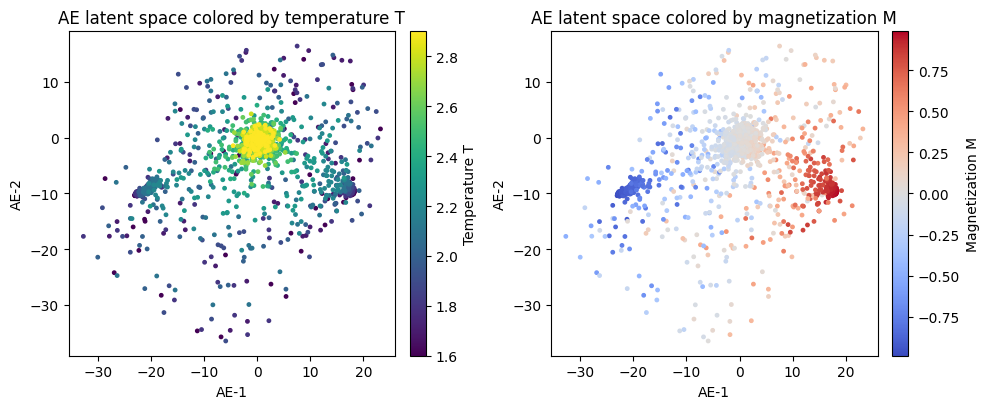

In [4]:
# --------------------- Stronger simple Autoencoder (ANN) in PyTorch ---------------------
# Assumes you already have: lattice_bank (n_samples x n_features), labels (temperatures).
# Produces a 5-D latent representation and plots the first two coordinates colored by T and by M.

import copy
import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "This notebook uses PyTorch for the stronger autoencoder. "
        "Install PyTorch in your notebook environment and rerun this cell."
    ) from exc

# ---------- Reproducibility and device selection ----------
# The exact numerical result can still vary slightly across CPU/GPU backends,
# but these settings make the run as reproducible as is practical for teaching.
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Deterministic algorithms improve reproducibility, but may be unavailable for
# some hardware/kernel combinations. The try/except keeps the notebook portable.
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Training device:", device)

# ---------- Prepare spin data ----------
# The dense AE is trained directly on spin values in {-1, +1}.
# This is better matched to the physics than standardizing each lattice site separately,
# because the output layer can reconstruct spin-like values with a tanh activation.
X_spins = lattice_bank.astype(np.float32)

# Robustly handle data stored as {0,1} instead of {-1,+1}.
unique_spin_values = np.unique(X_spins)
if set(np.round(unique_spin_values).astype(int)).issubset({0, 1}):
    X_spins = 2.0 * X_spins - 1.0

# Magnetization per configuration. This quantity is NOT used for training.
magnetization = X_spins.mean(axis=1)

# A small validation split is used only for early stopping.
# Stratifying by temperature ensures that every temperature is represented in both splits.
X_train, X_val, T_train, T_val = train_test_split(
    X_spins,
    labels,
    test_size=0.15,
    random_state=seed,
    stratify=labels
)

# ---------- Build a simple symmetric dense AE ----------
# Architecture:
# input -> 1024 -> 256 -> 64 -> 5 -> 64 -> 256 -> 1024 -> output
#
# Why this is still a "simple AE":
# - only dense layers are used,
# - the bottleneck remains low-dimensional (5 neurons),
# - no physics quantity is supplied to the model,
# - the loss is ordinary reconstruction MSE.
#
# Why it is stronger than the earlier sklearn MLP AE:
# - minibatch training is stable and configurable,
# - early stopping restores the best validation model,
# - the tanh output matches spin-valued data,
# - a small denoising step encourages the bottleneck to preserve robust, large-scale structure.
input_dim = X_spins.shape[1]
latent_dim = 5
noise_std = 0.05
l2_strength = 1e-6

class DenseSpinAutoencoder(nn.Module):
    """Simple dense autoencoder for flattened Ising spin configurations."""

    def __init__(self, input_dim, latent_dim=5, noise_std=0.05):
        super().__init__()
        self.noise_std = noise_std

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim),
            nn.Tanh(),
        )

    def forward(self, x):
        # Gaussian denoising is applied only during training, analogous to a
        # Keras GaussianNoise layer. It is not applied during validation or encoding.
        if self.training and self.noise_std > 0:
            x = x + self.noise_std * torch.randn_like(x)
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

    @torch.no_grad()
    def encode(self, x):
        self.eval()
        return self.encoder(x)

model = DenseSpinAutoencoder(input_dim=input_dim, latent_dim=latent_dim, noise_std=noise_std).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=l2_strength)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=1e-5,
)

# ---------- DataLoaders ----------
# TensorDataset stores the same tensor twice, because the AE target is the input itself.
batch_size = 64
train_tensor = torch.from_numpy(X_train).float()
val_tensor = torch.from_numpy(X_val).float()

train_loader = DataLoader(
    TensorDataset(train_tensor, train_tensor),
    batch_size=batch_size,
    shuffle=True,
    generator=torch.Generator().manual_seed(seed),
    num_workers=0,
)
val_loader = DataLoader(
    TensorDataset(val_tensor, val_tensor),
    batch_size=128,
    shuffle=False,
    num_workers=0,
)

# ---------- Training loop with early stopping ----------
max_epochs = 250
patience = 25
min_delta = 1e-5
best_val_loss = np.inf
best_state_dict = copy.deepcopy(model.state_dict())
epochs_without_improvement = 0
history = {"loss": [], "val_loss": []}

for epoch in range(1, max_epochs + 1):
    model.train()
    train_loss_sum = 0.0
    train_count = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        yhat = model(xb)
        loss = criterion(yhat, yb)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * xb.size(0)
        train_count += xb.size(0)

    train_loss = train_loss_sum / train_count

    model.eval()
    val_loss_sum = 0.0
    val_count = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            yhat = model(xb)
            loss = criterion(yhat, yb)
            val_loss_sum += loss.item() * xb.size(0)
            val_count += xb.size(0)

    val_loss = val_loss_sum / val_count
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    scheduler.step(val_loss)

    # Early stopping uses the same logic as the Keras version:
    # save the best validation model and stop after patience epochs without improvement.
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0 or epochs_without_improvement == 0:
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d} | train MSE {train_loss:.5f} | "
            f"val MSE {val_loss:.5f} | lr {current_lr:.1e}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping after {epoch} epochs. Best validation MSE: {best_val_loss:.5f}")
        break

# Restore the best validation model before encoding all configurations.
model.load_state_dict(best_state_dict)
model.eval()

# ---------- Encode and reconstruct all configurations ----------
# Keep the variable name `emb`, because the downstream validation cells use it.
all_tensor = torch.from_numpy(X_spins).float()
all_loader = DataLoader(TensorDataset(all_tensor), batch_size=128, shuffle=False, num_workers=0)

latent_batches = []
recon_batches = []
with torch.no_grad():
    for (xb,) in all_loader:
        xb = xb.to(device)
        z = model.encode(xb)
        xhat = model.decoder(z)
        latent_batches.append(z.cpu().numpy())
        recon_batches.append(xhat.cpu().numpy())

emb = np.vstack(latent_batches)
X_reconstructed = np.vstack(recon_batches)

# A reconstruction diagnostic is printed for transparency, but it is not used as one of the
# two physics-validation procedures. Low reconstruction error alone does not prove physics insight.
reconstruction_mse = np.mean((X_spins - X_reconstructed) ** 2)

print(f"Training stopped after {len(history['loss'])} epochs.")
print(f"Final training loss:          {history['loss'][-1]:.5f}")
print(f"Best validation loss:         {best_val_loss:.5f}")
print(f"All-sample reconstruction MSE:{reconstruction_mse:.5f}")
print("Latent representation shape:", emb.shape)

# --------------------- Plot first two latent coordinates ---------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
fig.subplots_adjust(wspace=0.20)

# (Left): colored by temperature
sc0 = axes[0].scatter(emb[:, 0], emb[:, 1], c=labels, cmap="viridis", s=6)
cbar0 = fig.colorbar(sc0, ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label("Temperature T")
axes[0].set_xlabel("AE-1")
axes[0].set_ylabel("AE-2")
axes[0].set_title("AE latent space colored by temperature T")

# (Right): colored by magnetization
sc1 = axes[1].scatter(emb[:, 0], emb[:, 1], c=magnetization, cmap="coolwarm", s=6)
cbar1 = fig.colorbar(sc1, ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label("Magnetization M")
axes[1].set_xlabel("AE-1")
axes[1].set_ylabel("AE-2")
axes[1].set_title("AE latent space colored by magnetization M")

plt.tight_layout()
png_path = "ising_AE_embedding_T_and_M_stronger_AE_torch.png"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
print("Saved:", png_path)

## Quantitative validation and physics interpretation: two compact procedures

The autoencoder was trained **without using temperature, magnetization, phase labels, or the Ising Hamiltonian**. The validation therefore uses physics quantities only *after training* to test whether the learned representation is physically meaningful.

The validation is deliberately restricted to two procedures.

**Procedure 1: latent-space physics validation.**  
This checks whether the AE bottleneck coordinates encode the order parameter and whether they separate the ferromagnetic and paramagnetic regimes. The relevant physics quantity is the magnetization per spin,
$M = \frac{1}{D}\sum_{j=1}^{D}s_j$,

where \(D=N^2\) is the number of lattice sites. Because the two ferromagnetic states with mostly up spins and mostly down spins are physically equivalent under global spin-flip symmetry, the validation uses \(|M|\) rather than only signed \(M\).

**Procedure 2: finite-size thermodynamic validation.**  
This checks whether the same configurations show the expected finite-size Ising behavior: \(\langle |M| \rangle\) decreases with temperature, magnetization fluctuations increase near the transition, and the finite-size transition indicators lie near the exact infinite-lattice value
\[
T_C = \frac{2}{\ln(1+\sqrt{2})} \approx 2.269 .
\]

These procedures complement the plot: the plot gives an exploratory visual representation, while the validation asks whether that representation is physically interpretable.


In [5]:
# --------------------- Validation setup ---------------------
# This cell collects the quantities needed by both validation procedures.
# None of these quantities were used to train the autoencoder.

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import RidgeCV, LogisticRegression
from sklearn.metrics import silhouette_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import display, Markdown
except ImportError:
    display = print
    Markdown = None

# Exact critical temperature of the infinite 2-D square-lattice Ising model
# in reduced units J/k_B = 1. This is a reference for interpretation only.
Tc_exact = 2.0 / np.log(1.0 + np.sqrt(2.0))

# Close to T_C, finite lattices show strong fluctuations and finite-size rounding.
# Excluding a narrow window prevents the binary phase validation from treating
# genuinely ambiguous near-critical configurations as cleanly ferro- or paramagnetic.
critical_window = 0.10

latent = np.asarray(emb, dtype=float)             # full 5-D AE bottleneck representation
latent_2d = latent[:, :2]                         # first two AE coordinates used in the figure
T_values_sample = np.asarray(labels, dtype=float) # simulation temperature of each configuration
M_signed = np.asarray(magnetization, dtype=float) # magnetization per spin, can be positive or negative
M_abs = np.abs(M_signed)                          # order-parameter magnitude; invariant under spin flip
D = flat_size                                     # number of lattice sites, D = N^2

phase_label = np.where(
    T_values_sample < Tc_exact - critical_window,
    "ferromagnetic",
    np.where(T_values_sample > Tc_exact + critical_window, "paramagnetic", "near-critical")
)
phase_mask = phase_label != "near-critical"
y_phase = (phase_label[phase_mask] == "paramagnetic").astype(int)

print(f"Exact infinite-lattice T_C = {Tc_exact:.4f} in units J/k_B = 1")
print(f"Binary phase validation excludes |T - T_C| < {critical_window:.2f}")
print("Phase counts used for post-hoc interpretation:")
for name, count in zip(*np.unique(phase_label, return_counts=True)):
    print(f"  {name:14s}: {count}")


Exact infinite-lattice T_C = 2.2692 in units J/k_B = 1
Binary phase validation excludes |T - T_C| < 0.10
Phase counts used for post-hoc interpretation:
  ferromagnetic : 600
  near-critical : 200
  paramagnetic  : 600


### Procedure 1 — Does the latent space encode the order parameter and phase separation?

This procedure quantifies whether the learned AE coordinates have physical meaning.

**Step 1: order-parameter recoverability.**  
A post-hoc regression predicts \(|M|\) from the five latent coordinates. This is a diagnostic only: the AE has already been trained, and the regressor is not used to improve the AE. A high cross-validated \(R^2\) means that the bottleneck contains information closely related to the conventional order parameter.

The readout uses quadratic latent features. This is physically motivated by the Ising spin-flip symmetry: the two ordered states \(M>0\) and \(M<0\) are equivalent, while \(|M|\) is an even quantity. A purely linear readout can underestimate the quality of a symmetric latent representation because it may place the two ordered branches on opposite sides of the origin.

**Step 2: geometric phase separation.**  
The silhouette score is computed using physics-defined ferro-/paramagnetic labels. This does not ask whether an algorithm has found clusters; it asks whether the known physical regimes occupy separated regions in latent space. The score is reported both in the full 5-D latent space and in the 2-D AE-1/AE-2 plot.

**Step 3: simple phase recoverability.**  
A cross-validated logistic-regression classifier predicts the phase label from the latent coordinates. As with the regression, this is a post-hoc diagnostic. It tests whether phase information is easily accessible from the AE representation. Balanced accuracy is used because it is less sensitive to unequal numbers of ferro- and paramagnetic samples.


In [6]:
# --------------------- Procedure 1: latent-space physics validation ---------------------
# Goal: quantify whether the AE representation encodes (i) the order parameter |M|
# and (ii) the separation between ferromagnetic and paramagnetic configurations.

# --- Step 1: post-hoc regression from latent variables to |M| ---
# PolynomialFeatures(degree=2) is used for a simple symmetry-aware readout.
# It can represent even relations such as |M| varying with the squared distance
# from the disordered region in latent space.
cv_reg = KFold(n_splits=5, shuffle=True, random_state=seed)
order_parameter_regressor = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-6, 6, 13))
)

r2_absM = cross_val_score(
    order_parameter_regressor,
    latent,
    M_abs,
    cv=cv_reg,
    scoring="r2"
)

# --- Step 2: silhouette score for physics-defined phases ---
# The latent variables are standardized before computing distances, because the
# numerical scale of individual latent neurons is arbitrary.
phase_metrics = {}
if len(np.unique(y_phase)) == 2 and phase_mask.sum() > 2:
    latent_phase_5d = StandardScaler().fit_transform(latent[phase_mask])
    latent_phase_2d = StandardScaler().fit_transform(latent_2d[phase_mask])
    phase_metrics["silhouette_5d"] = float(silhouette_score(latent_phase_5d, y_phase))
    phase_metrics["silhouette_2d"] = float(silhouette_score(latent_phase_2d, y_phase))

    # --- Step 3: simple phase recovery from latent coordinates ---
    # The same quadratic feature map is used because the ferromagnetic phase can appear
    # as two symmetry-related branches. A linear boundary alone may be too restrictive.
    class_counts = np.bincount(y_phase)
    n_splits = min(5, class_counts.min())
    if n_splits >= 2:
        phase_classifier = make_pipeline(
            StandardScaler(),
            PolynomialFeatures(degree=2, include_bias=False),
            StandardScaler(),
            LogisticRegression(max_iter=3000, class_weight="balanced", random_state=seed)
        )
        cv_clf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        balanced_acc = cross_val_score(
            phase_classifier,
            latent[phase_mask],
            y_phase,
            cv=cv_clf,
            scoring="balanced_accuracy"
        )
        phase_metrics["balanced_accuracy"] = float(balanced_acc.mean())
        phase_metrics["balanced_accuracy_std"] = float(balanced_acc.std(ddof=1))

print("Procedure 1: latent-space physics validation")
print(f"  |M| prediction R^2 from 5-D latent space: {r2_absM.mean():.3f} ± {r2_absM.std(ddof=1):.3f}")
if phase_metrics:
    print(f"  Silhouette score, 5-D latent space:      {phase_metrics.get('silhouette_5d', np.nan):.3f}")
    print(f"  Silhouette score, AE-1/AE-2 plot:        {phase_metrics.get('silhouette_2d', np.nan):.3f}")
    if "balanced_accuracy" in phase_metrics:
        print(
            "  Balanced phase-classification accuracy: "
            f"{phase_metrics['balanced_accuracy']:.3f} ± {phase_metrics['balanced_accuracy_std']:.3f}"
        )
else:
    print("  Phase-separation metrics could not be computed; check phase counts and critical window.")

# A compact automatic interpretation is printed to help students read their own results.
def describe_r2(value):
    if value >= 0.80:
        return "strong evidence that the latent space encodes the order-parameter magnitude"
    if value >= 0.50:
        return "moderate evidence that the latent space encodes the order-parameter magnitude"
    if value >= 0.20:
        return "weak but nontrivial evidence for order-parameter information"
    return "little evidence that |M| is recoverable from the latent space"

def describe_acc(value):
    if value >= 0.85:
        return "strong phase recoverability"
    if value >= 0.70:
        return "moderate phase recoverability"
    if value >= 0.60:
        return "weak but above-chance phase recoverability"
    return "near-chance phase recoverability"

print("\nAutomatic quality interpretation:")
print(f"  Order-parameter readout: {describe_r2(r2_absM.mean())}.")
if "balanced_accuracy" in phase_metrics:
    print(f"  Phase readout: {describe_acc(phase_metrics['balanced_accuracy'])}.")
print("  Treat silhouette scores cautiously because the ferromagnetic phase may form two symmetry-related branches.")


Procedure 1: latent-space physics validation
  |M| prediction R^2 from 5-D latent space: 0.950 ± 0.007
  Silhouette score, 5-D latent space:      0.316
  Silhouette score, AE-1/AE-2 plot:        0.344
  Balanced phase-classification accuracy: 0.993 ± 0.006

Automatic quality interpretation:
  Order-parameter readout: strong evidence that the latent space encodes the order-parameter magnitude.
  Phase readout: strong phase recoverability.
  Treat silhouette scores cautiously because the ferromagnetic phase may form two symmetry-related branches.


### Interpretation of Procedure 1 quality

Use the printed values above to decide how strongly the AE latent space supports a physics interpretation.

A **strong Procedure 1 result** would typically show a high cross-validated \(|M|\)-prediction score, for example \(R^2 \gtrsim 0.8\), together with clearly above-chance phase recovery, for example balanced accuracy \(\gtrsim 0.8\). This would mean that the unsupervised bottleneck has not merely compressed the spin configurations, but has organized them in a way that makes the conventional order parameter and the ferro-/paramagnetic distinction easy to recover.

A **moderate result** might have \(R^2 \approx 0.5\)–\(0.8\) and balanced accuracy around \(0.7\)–\(0.8\). This is still useful for teaching: students can see that the AE has captured part of the magnetic structure, but not enough to replace explicit physical observables.

A **weak result** has \(R^2\) near zero or negative and balanced accuracy near \(0.5\). In that case, the plot should be interpreted as exploratory visualization only. It would not be justified to claim that the AE has identified the magnetic phases.

The silhouette score is helpful but should not be overemphasized. The ferromagnetic phase is not necessarily one compact cluster: the \(M>0\) and \(M<0\) states are symmetry-related but may lie in two different regions of latent space. Therefore, a low silhouette score can occur even when the representation contains useful phase information. For this reason, the \(|M|\) readout and balanced phase accuracy are usually more informative than silhouette alone.


### Procedure 2 — Are the data and the learned interpretation consistent with the finite-size Ising transition?

This procedure validates the **physics interpretation** of the latent-space plot. If regions in latent space are interpreted as magnetic phases, then conventional thermodynamic observables computed from the same configurations should show the expected finite-size transition behavior.

The calculation proceeds in three steps.

**Step 1: temperature dependence of the order parameter.**  
For each simulated temperature, the notebook computes the mean order-parameter magnitude,
\[
\langle |M| \rangle_T .
\]
In the ordered regime below \(T_C\), \(\langle |M| \rangle_T\) should be large. Above \(T_C\), it should decrease toward zero because thermal fluctuations destroy long-range order.

**Step 2: finite-size susceptibility.**  
The notebook computes the fluctuation-based susceptibility,
\[
\chi(T) = \frac{D}{T}\left(\langle M^2\rangle_T-\langle M\rangle_T^2\right),
\]
where \(D=N^2\). Around a phase transition, magnetization fluctuations become large. For a finite lattice, this appears as a broad peak rather than an infinite singularity.

**Step 3: transition-region indicators.**  
The notebook estimates the transition region in two simple ways: the temperature at which \(\langle |M| \rangle_T\) changes most steeply, and the temperature at which \(\chi(T)\) is maximal. Both should lie near the exact infinite-lattice value \(T_C\), but they need not match it exactly because the simulation uses a finite \(80\times 80\) lattice and a discrete temperature grid.


,T,n_samples,mean_abs_M,std_abs_M,mean_M
0,1.6,100,0.743609,0.353349,0.005822
1,1.7,100,0.644097,0.388604,-0.048116
2,1.8,100,0.680066,0.358113,-0.006766
3,1.9,100,0.651594,0.339753,-0.036350
4,2.0,100,0.633419,0.296698,-0.050088
5,2.1,100,0.592775,0.306515,-0.135894
6,2.2,100,0.569963,0.248140,0.092419
7,2.3,100,0.307453,0.192651,0.064459
8,2.4,100,0.112641,0.086760,-0.008278
9,2.5,100,0.077784,0.058998,-0.009703



Procedure 2: finite-size transition indicators
  exact infinite-lattice T_C:             2.269
  steepest change of <|M|> at T ≈        2.300  (|ΔT| = 0.031)
  susceptibility peak at T ≈             1.600  (|ΔT| = 0.669)
  Finite-size simulations are expected to show rounded, shifted indicators rather than an exact singularity.

Automatic quality interpretation:
  <|M|> slope indicator is very close to the exact infinite-lattice value.
  Susceptibility indicator is far from the expected region; the data or simulation protocol should be checked.


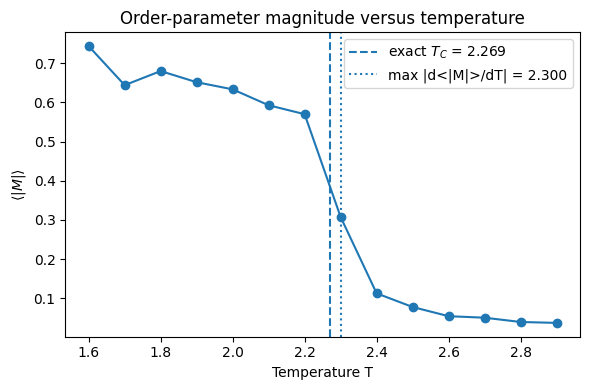

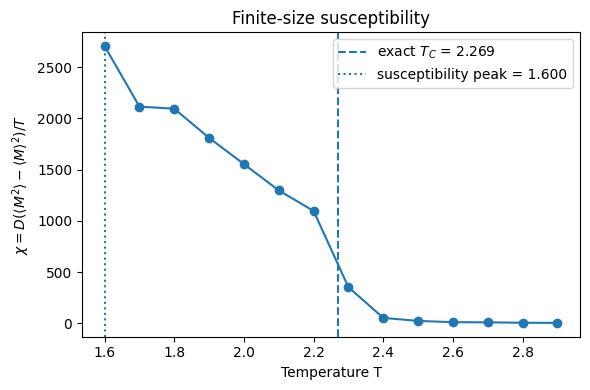

In [7]:
# --------------------- Procedure 2: finite-size thermodynamic validation ---------------------
# Goal: check whether conventional observables extracted from the same configurations
# show the expected finite-size transition behavior near the known Ising T_C.

unique_T = np.array(sorted(np.unique(T_values_sample)))
summary_rows = []

for T in unique_T:
    mask_T = T_values_sample == T
    M_T = M_signed[mask_T]
    absM_T = M_abs[mask_T]
    summary_rows.append({
        "T": float(T),
        "n_samples": int(mask_T.sum()),
        "mean_abs_M": float(absM_T.mean()),
        "std_abs_M": float(absM_T.std(ddof=1)),
        "mean_M": float(M_T.mean()),
        "mean_M2": float((M_T ** 2).mean()),
    })

if pd is not None:
    thermodynamic_summary = pd.DataFrame(summary_rows)
    display(thermodynamic_summary[["T", "n_samples", "mean_abs_M", "std_abs_M", "mean_M"]])
else:
    thermodynamic_summary = summary_rows
    for row in summary_rows:
        print(row)

mean_abs_M = np.array([row["mean_abs_M"] for row in summary_rows])
mean_M = np.array([row["mean_M"] for row in summary_rows])
mean_M2 = np.array([row["mean_M2"] for row in summary_rows])

# Susceptibility in reduced units. Since M is magnetization per spin, multiplying by D=N^2
# converts the variance of M into the usual extensive fluctuation scale.
chi = D * (mean_M2 - mean_M ** 2) / unique_T

# The derivative is numerical because the simulated temperatures are discrete.
# The maximum absolute slope marks the strongest finite-size change of the order parameter.
d_absM_dT = np.gradient(mean_abs_M, unique_T)
Tc_from_slope = float(unique_T[np.argmax(np.abs(d_absM_dT))])
Tc_from_chi = float(unique_T[np.argmax(chi)])

delta_slope = abs(Tc_from_slope - Tc_exact)
delta_chi = abs(Tc_from_chi - Tc_exact)

print("\nProcedure 2: finite-size transition indicators")
print(f"  exact infinite-lattice T_C:             {Tc_exact:.3f}")
print(f"  steepest change of <|M|> at T ≈        {Tc_from_slope:.3f}  (|ΔT| = {delta_slope:.3f})")
print(f"  susceptibility peak at T ≈             {Tc_from_chi:.3f}  (|ΔT| = {delta_chi:.3f})")
print("  Finite-size simulations are expected to show rounded, shifted indicators rather than an exact singularity.")

plt.figure(figsize=(6, 4))
plt.plot(unique_T, mean_abs_M, marker="o")
plt.axvline(Tc_exact, linestyle="--", label=f"exact $T_C$ = {Tc_exact:.3f}")
plt.axvline(Tc_from_slope, linestyle=":", label=f"max |d<|M|>/dT| = {Tc_from_slope:.3f}")
plt.xlabel("Temperature T")
plt.ylabel(r"$\langle |M| \rangle$")
plt.title("Order-parameter magnitude versus temperature")
plt.legend()
plt.tight_layout()

plt.figure(figsize=(6, 4))
plt.plot(unique_T, chi, marker="o")
plt.axvline(Tc_exact, linestyle="--", label=f"exact $T_C$ = {Tc_exact:.3f}")
plt.axvline(Tc_from_chi, linestyle=":", label=f"susceptibility peak = {Tc_from_chi:.3f}")
plt.xlabel("Temperature T")
plt.ylabel(r"$\chi = D(\langle M^2\rangle - \langle M\rangle^2)/T$")
plt.title("Finite-size susceptibility")
plt.legend()
plt.tight_layout()

def describe_tc_offset(delta):
    # The temperature grid is coarse, so offsets of about one grid spacing are generally acceptable.
    if delta <= 0.10:
        return "very close to the exact infinite-lattice value"
    if delta <= 0.25:
        return "reasonably close, given finite-size rounding and the discrete temperature grid"
    if delta <= 0.40:
        return "somewhat shifted; inspect sampling, equilibration, and temperature resolution"
    return "far from the expected region; the data or simulation protocol should be checked"

print("\nAutomatic quality interpretation:")
print(f"  <|M|> slope indicator is {describe_tc_offset(delta_slope)}.")
print(f"  Susceptibility indicator is {describe_tc_offset(delta_chi)}.")


Saved: ising_order_parameter_magnitude_vs_temperature.png
Exact infinite-lattice Tc: 2.269
Finite-size steepest-change estimate: 2.30


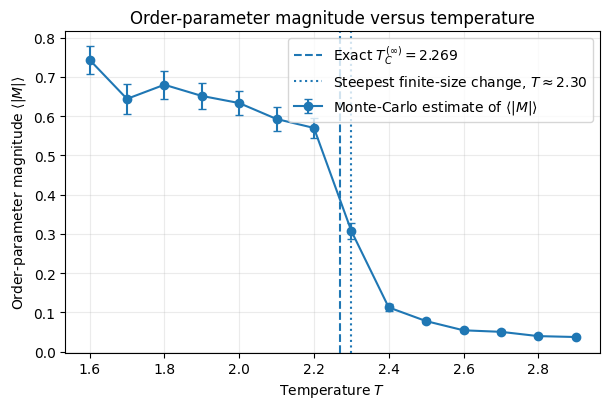

In [11]:
# Code for saving the order-parameter versus temperature plot:

# Exact infinite-lattice critical temperature for the 2D square-lattice Ising model
# in units where J/k_B = 1.
T_c_exact = 2.0 / np.log(1.0 + np.sqrt(2.0))

df_order = pd.DataFrame({
    "T": np.asarray(labels, dtype=float),
    "M": np.asarray(magnetization, dtype=float),
    "absM": np.abs(np.asarray(magnetization, dtype=float))
})

order_stats = (
    df_order
    .groupby("T")
    .agg(
        absM_mean=("absM", "mean"),
        absM_std=("absM", "std"),
        n=("absM", "count")
    )
    .reset_index()
    .sort_values("T")
)

order_stats["absM_sem"] = order_stats["absM_std"] / np.sqrt(order_stats["n"])

T_values = order_stats["T"].to_numpy()
absM_mean = order_stats["absM_mean"].to_numpy()
absM_sem = order_stats["absM_sem"].to_numpy()

# Finite-size estimate from the steepest decrease of <|M|>.
# This is not expected to equal the exact infinite-lattice Tc exactly.
d_absM_dT = np.gradient(absM_mean, T_values)
T_steepest = T_values[np.argmin(d_absM_dT)]

fig, ax = plt.subplots(figsize=(6.2, 4.2))

ax.errorbar(
    T_values,
    absM_mean,
    yerr=absM_sem,
    marker="o",
    linestyle="-",
    capsize=3,
    label=r"Monte-Carlo estimate of $\langle |M| \rangle$"
)

ax.axvline(
    T_c_exact,
    linestyle="--",
    label=rf"Exact $T_C^{{(\infty)}}={T_c_exact:.3f}$"
)

ax.axvline(
    T_steepest,
    linestyle=":",
    label=rf"Steepest finite-size change, $T\approx {T_steepest:.2f}$"
)

ax.set_xlabel(r"Temperature $T$")
ax.set_ylabel(r"Order-parameter magnitude $\langle |M| \rangle$")
ax.set_title(r"Order-parameter magnitude versus temperature")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()

png_path = "ising_order_parameter_magnitude_vs_temperature.png"
fig.savefig(png_path, dpi=300, bbox_inches="tight")

print("Saved:", png_path)
print(f"Exact infinite-lattice Tc: {T_c_exact:.3f}")
print(f"Finite-size steepest-change estimate: {T_steepest:.2f}")

### Interpretation of Procedure 2 quality

A **strong Procedure 2 result** has two qualitative features. First, \(\langle |M| \rangle\) should decrease substantially as temperature increases: large values at low temperature indicate ordered ferromagnetic configurations, while small values at high temperature indicate disordered paramagnetic configurations. Second, the susceptibility should show a visible peak near the known critical region.

The transition indicators do **not** have to equal \(T_C=2.269\) exactly. This notebook uses a finite \(80\times 80\) lattice, a finite number of Monte Carlo samples, and a discrete temperature grid. Therefore, the transition is rounded and the estimated peak can be shifted by roughly one or more grid spacings. Agreement within about \(0.1\)–\(0.25\) is usually a good sign for this kind of educational finite-size demonstration.

If \(\langle |M| \rangle\) does not decrease with temperature, or if the susceptibility peak is far away from \(T_C\), the issue is probably not the AE alone. It may indicate that the Monte Carlo data are not equilibrated, that too few samples were used, that the temperature range misses the transition, or that the spin encoding was interpreted incorrectly.

Procedure 2 is important because it anchors the ML visualization in conventional statistical physics. The AE may suggest a low-dimensional organization of the configurations, but the thermodynamic observables explain why that organization corresponds to magnetic ordering, disordering, fluctuations, and finite-size critical behavior.


In [9]:
validation_summary = {
    "reconstruction_mse": float(reconstruction_mse),
    "Tc_exact": float(Tc_exact),
    "Tc_from_slope": float(Tc_from_slope),
    "Tc_from_chi": float(Tc_from_chi),
    "delta_slope": float(delta_slope),
    "delta_chi": float(delta_chi),
    "r2_absM_mean": float(r2_absM.mean()),
    "r2_absM_std": float(r2_absM.std(ddof=1)),
    **phase_metrics,
}

print("Validation summary dictionary:")
for key, value in validation_summary.items():
    print(f"  {key:28s}: {value:.3f}")

# Latex output for the paper:
print(
    "Two post-hoc validation procedures were used. First, a symmetry-aware quadratic readout from "
    f"the five AE latent variables recovered the order-parameter magnitude with cross-validated "
    f"$R^2={validation_summary['r2_absM_mean']:.2f}\\pm{validation_summary['r2_absM_std']:.2f}$ "
    f"and separated the physics-defined phases with balanced accuracy "
    f"${validation_summary.get('balanced_accuracy', float('nan')):.2f}"
    f"\\pm{validation_summary.get('balanced_accuracy_std', float('nan')):.2f}$. "
    "Second, finite-size thermodynamic indicators placed the transition region near "
    f"$T\\approx{validation_summary['Tc_from_slope']:.2f}$ from the steepest change in "
    f"$\\langle |M| \\rangle$ and $T\\approx{validation_summary['Tc_from_chi']:.2f}$ from the "
    f"susceptibility peak, compared with the exact infinite-lattice value "
    f"$T_C={validation_summary['Tc_exact']:.3f}$."
)


Validation summary dictionary:
  reconstruction_mse          : 0.591
  Tc_exact                    : 2.269
  Tc_from_slope               : 2.300
  Tc_from_chi                 : 1.600
  delta_slope                 : 0.031
  delta_chi                   : 0.669
  r2_absM_mean                : 0.950
  r2_absM_std                 : 0.007
  silhouette_5d               : 0.316
  silhouette_2d               : 0.344
  balanced_accuracy           : 0.993
  balanced_accuracy_std       : 0.006
Two post-hoc validation procedures were used. First, a symmetry-aware quadratic readout from the five AE latent variables recovered the order-parameter magnitude with cross-validated $R^2=0.95\pm0.01$ and separated the physics-defined phases with balanced accuracy $0.99\pm0.01$. Second, finite-size thermodynamic indicators placed the transition region near $T\approx2.30$ from the steepest change in $\langle |M| \rangle$ and $T\approx1.60$ from the susceptibility peak, compared with the exact infinite-lattice

### Final teaching interpretation

A successful run should not be interpreted as the autoencoder “discovering physics from nothing.” The AE learns only from reconstruction. The physics meaning is established afterwards by comparing the latent representation with the order parameter, phase labels, and finite-size thermodynamic observables.

Procedure 1 asks whether the latent space contains the same information that physicists usually summarize through \(|M|\) and phase labels. Procedure 2 asks whether those labels and observables behave like an Ising system near a finite-size transition. Together, they show how ML can complement traditional modeling: the AE provides a compact representation of many configurations, while statistical physics explains the representation through symmetry breaking, magnetization, fluctuations, and critical behavior.
